In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Device setup — use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {device}")

PyTorch version : 2.11.0+cu128
Device          : cuda


100%|██████████| 26.4M/26.4M [00:01<00:00, 13.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 205kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.76MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 3.91MB/s]


Training samples : 60000
Testing  samples : 10000
Batches per epoch: 469


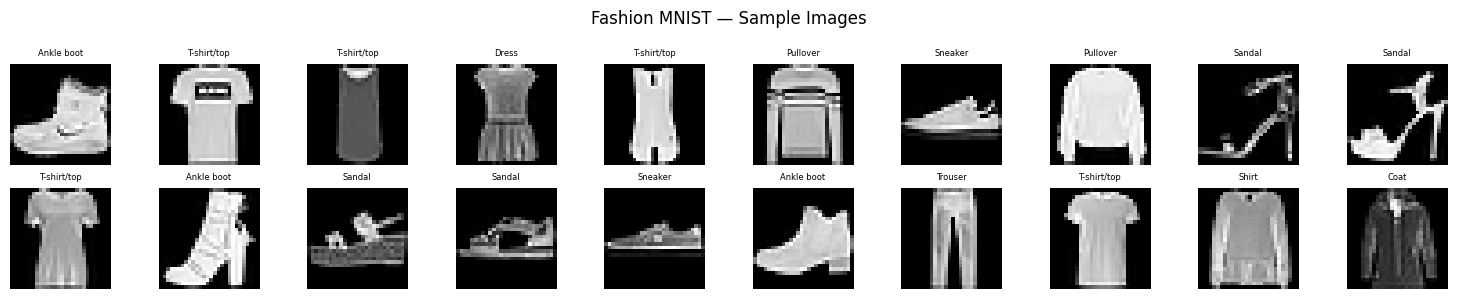

In [ ]:
# Transform: convert to tensor and normalize to [0, 1]
transform = transforms.Compose([
    transforms.ToTensor()
])

# Load datasets directly — no CSV download needed
train_dataset = datasets.FashionMNIST(root="./data", train=True,
                                       download=True, transform=transform)
test_dataset  = datasets.FashionMNIST(root="./data", train=False,
                                       download=True, transform=transform)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False)

# Class names
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

print(f"Training samples : {len(train_dataset)}")
print(f"Testing  samples : {len(test_dataset)}")
print(f"Batches per epoch: {len(train_loader)}")

# Visualize sample images
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(20):
    img, label = train_dataset[i]
    axes[i//10][i%10].imshow(img.squeeze(), cmap="gray")
    axes[i//10][i%10].set_title(class_names[label], fontsize=6)
    axes[i//10][i%10].axis("off")
plt.suptitle("Fashion MNIST — Sample Images", fontsize=12)
plt.tight_layout()
plt.show()






# Prepare the Fashion-MNIST dataset and visualize representative training samples

# - Configure the image preprocessing pipeline for the Fashion-MNIST dataset.
# - Download and load the training and testing datasets into DataLoaders for mini-batch processing.
# - Display sample images with their corresponding class labels to verify dataset integrity and familiarize with the classification categories.


# Load, preprocess, and inspect the Fashion-MNIST dataset using PyTorch DataLoaders

# - Define an image transformation pipeline using `transforms.Compose()`, where `transforms.ToTensor()` converts each grayscale image into a PyTorch tensor while scaling pixel values from the range `[0,255]` to `[0,1]`.
#   Example:
#     Original pixel = 255
#     After ToTensor() = 1.0

#     Original pixel = 128
#     After ToTensor() ≈ 0.502
#   This normalization provides a consistent input range for neural network training.
# - Download and load both the Fashion-MNIST training and testing datasets using `datasets.FashionMNIST()`.
#   - The training dataset contains 60,000 labeled clothing images.
#   - The testing dataset contains 10,000 unseen images used for model evaluation.
#   The specified transformation is automatically applied whenever an image is accessed.
# - Create `DataLoader` objects for both datasets to enable efficient mini-batch processing during training and testing.
#   - `batch_size=128` groups 128 images into each training iteration.
#   - `shuffle=True` randomly rearranges the training data every epoch, preventing the model from learning the order of the dataset.
#   - `shuffle=False` preserves the original ordering of the test data to ensure consistent evaluation results.
# - Define a list of human-readable class names corresponding to the dataset's numeric labels.
#   Example:
#     Label 0 → T-shirt/top
#     Label 5 → Sandal
#     Label 9 → Ankle boot
#   This mapping makes later visualizations and predictions easier to interpret.
# - Display basic dataset statistics, including:
#   - Total number of training samples.
#   - Total number of testing samples.
#   - Number of mini-batches processed during each training epoch.
#   These values verify that the dataset has been loaded successfully and provide an overview of the training workload.
# - Visualize the first 20 training images in a 2×10 grid using Matplotlib.
#   For each sample:
#   - Retrieve the image and its numeric label.
#   - Display the grayscale image using `imshow()`.
#   - Replace the numeric label with its corresponding clothing category from `class_names`.
#   - Hide axis markings to produce a cleaner visualization.
# - Add an overall title and adjust the layout so all sample images are displayed clearly without overlapping labels.
# - Use this visualization as an initial sanity check to confirm that:
#   - Images have been loaded correctly.
#   - Labels match the displayed clothing items.
#   - The preprocessing pipeline is functioning as expected before training any deep learning models.





# Load, preprocess, batch, and inspect the Fashion-MNIST dataset before training the neural network

# - Define an image preprocessing pipeline using `transforms.Compose()`. A transformation pipeline applies one or more preprocessing operations sequentially to every image before it is fed into the neural network.
# - Use `transforms.ToTensor()` as the first preprocessing step to convert each Fashion-MNIST image from a PIL image into a PyTorch tensor while scaling pixel values from the range `[0,255]` to `[0,1]`.
#   Example:
#     Pixel value = 255  →  1.0
#     Pixel value = 128  →  0.502
#     Pixel value =   0  →  0.0
#   Neural networks cannot process PIL images directly—they require numerical tensors. Converting images to tensors also standardizes the input format expected by PyTorch layers.
# - Wrap the preprocessing step inside `transforms.Compose()` even though only one transformation is currently used. This creates a reusable preprocessing pipeline that can easily be extended later with operations such as image resizing, normalization, random rotations, or data augmentation without changing the dataset-loading code.
# - Download and load the Fashion-MNIST training and testing datasets using `datasets.FashionMNIST()`. The transformation pipeline is automatically applied every time an image is retrieved from the dataset.
# - Create `DataLoader` objects for both datasets to efficiently feed data to the neural network during training and evaluation. Instead of loading all images into memory at once, the DataLoader divides the dataset into smaller mini-batches that are processed one batch at a time.
#   Example:
#       60,000 Training Images
#                │
#                ▼
#         Batch 1 (128 images)
#         Batch 2 (128 images)
#         Batch 3 (128 images)
#                ...
#   This mini-batch strategy significantly reduces memory usage and enables efficient gradient-based optimization.
# - Configure `batch_size=128` so that each training iteration processes 128 images simultaneously. Processing mini-batches provides a good balance between computational efficiency and stable gradient estimation during backpropagation.
# - Enable `shuffle=True` for the training DataLoader so that the training images are randomly reordered before every epoch. Randomizing the order prevents the model from memorizing the sequence of the dataset and improves its ability to generalize to unseen data.
# - Use `shuffle=False` for the testing DataLoader because the model is only being evaluated. Keeping the testing order fixed ensures consistent and reproducible evaluation results across multiple runs.
# - Define a list of human-readable class names that maps each numeric label to its corresponding clothing category.
#   Example:
#       0 → T-shirt/top
#       5 → Sandal
#       9 → Ankle boot
#   This mapping makes visualizations and prediction outputs easier to interpret.
# - Print dataset statistics, including the number of training samples, testing samples, and mini-batches per epoch, to verify that the dataset has been loaded correctly.
# - Display the first 20 training images in a 2×10 grid using Matplotlib. For each image:
#   - Retrieve the image and its numeric label.
#   - Display the grayscale image.
#   - Replace the numeric label with its corresponding clothing category.
#   - Hide the axes for a cleaner visualization.
# - Use the visualization as a sanity check before training to confirm that the images, labels, preprocessing pipeline, and DataLoader are all functioning correctly and that the dataset is ready to be supplied to the neural network.

In [ ]:
class Encoder(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()

        # Convolutional feature extractor
        self.conv = nn.Sequential(
            # 1×28×28 → 32×14×14
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),

            # 32×14×14 → 64×7×7
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),

            # 64×7×7 → 128×4×4
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
        )

        # Flatten → Dense → mu and log_var
        self.flatten    = nn.Flatten()
        self.fc_mu      = nn.Linear(128 * 4 * 4, latent_dim)
        self.fc_log_var = nn.Linear(128 * 4 * 4, latent_dim)

    def forward(self, x):
        x       = self.conv(x)
        x       = self.flatten(x)
        mu      = self.fc_mu(x)
        log_var = self.fc_log_var(x)
        return mu, log_var


# Quick test
encoder = Encoder(latent_dim=2)
test_input = torch.randn(1, 1, 28, 28)
mu, log_var = encoder(test_input)
print(f"Input shape   : {test_input.shape}")
print(f"mu shape      : {mu.shape}")
print(f"log_var shape : {log_var.shape}")









# Implement the convolutional encoder for the Variational Autoencoder

# - Build a convolutional encoder that progressively extracts hierarchical image features and compresses them into a low-dimensional latent representation.
# - Produce the latent distribution parameters (mean and log variance) required for probabilistic sampling in the VAE.
# - Validate the encoder architecture by performing a forward pass on a sample input and verifying the output tensor shapes.




# Construct a convolutional feature extractor that encodes input images into the latent distribution of a Variational Autoencoder

# - Define the `Encoder` class by inheriting from `nn.Module`, allowing the encoder to integrate seamlessly with PyTorch's neural network framework and automatic differentiation.
# - Build the feature extractor using a sequence of convolutional layers (`nn.Sequential`) instead of fully connected layers. Convolutional layers preserve the spatial structure of images and learn local patterns such as edges, textures, and shapes, making them more suitable for image data than flattening the image at the beginning.
# - Apply three convolutional blocks, each consisting of:
#   - A `Conv2d` layer for feature extraction.
#   - A `ReLU` activation to introduce non-linearity.
#   Each convolution uses `kernel_size=3`, `stride=2`, and `padding=1`, allowing the network to simultaneously extract features while reducing the spatial dimensions of the feature maps.
# - Progressively transform the input image through the convolutional layers:
#   Example:
#       Input Image      : (1, 28, 28)
#             │
#             ▼
#       Conv1 + ReLU     : (32, 14, 14)
#             │
#             ▼
#       Conv2 + ReLU     : (64, 7, 7)
#             │
#             ▼
#       Conv3 + ReLU     : (128, 4, 4)
#   As the image resolution decreases, the number of feature channels increases, allowing the encoder to capture increasingly complex visual patterns while compressing the input information.
# - Flatten the final feature map using `nn.Flatten()`, converting the three-dimensional tensor `(128 × 4 × 4)` into a one-dimensional feature vector of length `2048`, which can be processed by fully connected layers.
# - Create two independent fully connected layers:
#   - `fc_mu` predicts the latent mean (`μ`).
#   - `fc_log_var` predicts the latent log variance (`log_var`).
#   Instead of producing a single latent vector, a Variational Autoencoder models each input as a Gaussian probability distribution.
#   Example:
#       Feature Vector
#             │
#       ┌─────┴─────┐
#       ▼           ▼
#       μ        log_var
# - Use `log_var` instead of the variance directly because variances must remain positive. Predicting the logarithm of the variance improves numerical stability during training and allows the actual standard deviation to be computed safely during the reparameterization step.
# - Implement the `forward()` method to define the data flow through the encoder:
#   - Extract hierarchical image features using the convolutional blocks.
#   - Flatten the resulting feature maps.
#   - Compute the latent mean (`μ`) and log variance (`log_var`).
#   - Return both tensors for subsequent latent sampling.
# - Perform a quick validation by creating a random input tensor with shape `(1, 1, 28, 28)`, representing a single grayscale Fashion-MNIST image.
# - Pass the sample image through the encoder and print the shapes of the input, latent mean, and latent log variance to verify that the architecture produces correctly sized latent representations before integrating it into the complete Variational Autoencoder.




Input shape   : torch.Size([1, 1, 28, 28])
mu shape      : torch.Size([1, 2])
log_var shape : torch.Size([1, 2])


In [ ]:
class Decoder(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()

        # Project latent vector back to 128×4×4
        self.fc = nn.Linear(latent_dim, 128 * 4 * 4)

        # Transposed convolutions — reverse of encoder
        self.deconv = nn.Sequential(
            # 128×4×4 → 64×7×7
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2,
                               padding=1, output_padding=0),
            nn.ReLU(),

            # 64×7×7 → 32×14×14
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2,
                               padding=1, output_padding=1),
            nn.ReLU(),

            # 32×14×14 → 1×28×28
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2,
                               padding=1, output_padding=1),
            nn.Sigmoid()   # output pixel values in [0, 1]
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 128, 4, 4)   # reshape to 3D feature map
        x = self.deconv(x)
        return x


# Quick test
decoder = Decoder(latent_dim=2)
test_z  = torch.randn(1, 2)
out     = decoder(test_z)
print(f"Latent input shape  : {test_z.shape}")
print(f"Reconstructed shape : {out.shape}")









# Implement the convolutional decoder for the Variational Autoencoder

# - Build the decoder responsible for reconstructing images from latent vectors.
# - Project the low-dimensional latent representation into a high-dimensional feature map using a fully connected layer.
# - Gradually upsample the feature maps using transposed convolution layers until the original image size is restored.
# - Produce reconstructed grayscale images with pixel values constrained to the valid range [0,1].
# - Validate the decoder architecture by performing a forward pass on a sample latent vector and verifying the reconstructed output shape.





# Construct the decoder by transforming latent vectors back into full-resolution images using fully connected and transposed convolution layers

# - Define the `Decoder` class by inheriting from `nn.Module`, allowing it to function as the image reconstruction component of the Variational Autoencoder.
# - Create a fully connected (`Linear`) layer that expands the compact latent vector into a higher-dimensional representation suitable for convolutional processing.
#   Example:
#       Latent Vector (2 values)
#               │
#               ▼
#       Fully Connected Layer
#               │
#               ▼
#       128 × 4 × 4 Feature Map
# - Reshape the output of the fully connected layer from a one-dimensional vector into a three-dimensional feature map using `view()`, preparing it for transposed convolution operations.
# - Build the decoder using a sequence of `ConvTranspose2d` layers, which perform the opposite operation of standard convolutions by increasing the spatial dimensions of feature maps while reducing the number of feature channels.
# - Apply three transposed convolution blocks to progressively reconstruct the original image resolution:
#   Example:
#       128 × 4 × 4
#             │
#             ▼
#       64 × 7 × 7
#             │
#             ▼
#       32 × 14 × 14
#             │
#             ▼
#        1 × 28 × 28
# - Use `ReLU` activation functions after each intermediate transposed convolution to introduce non-linearity and enable the decoder to learn complex image reconstruction patterns.
# - Apply a final `Sigmoid` activation so that every output pixel lies within the range `[0,1]`, matching the normalized pixel values used during training.
# - Implement the `forward()` method to define the complete reconstruction pipeline:
#   - Expand the latent vector using the fully connected layer.
#   - Reshape it into a feature map.
#   - Pass it through the transposed convolution layers.
#   - Return the reconstructed image.
# - Perform a quick validation by generating a random latent vector of shape `(1, 2)` and passing it through the decoder to confirm that the reconstructed output has the expected dimensions `(1, 1, 28, 28)`, verifying that the decoder correctly reverses the encoder's compression process.




Latent input shape  : torch.Size([1, 2])
Reconstructed shape : torch.Size([1, 1, 28, 28])


In [ ]:
class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self, mu, log_var):
        # During training: sample z = mu + epsilon * std
        # During eval: just return mu (deterministic)
        if self.training:
            std     = torch.exp(0.5 * log_var)   # std = e^(0.5 * log_var)
            epsilon = torch.randn_like(std)        # sample from N(0,1)
            return mu + epsilon * std
        return mu

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z           = self.reparameterize(mu, log_var)
        x_recon     = self.decoder(z)
        return x_recon, mu, log_var


# Build model and move to device
model = VAE(latent_dim=2).to(device)

# Quick test — full forward pass
test_input          = torch.randn(4, 1, 28, 28).to(device)
x_recon, mu, log_var = model(test_input)

print(f"Input shape       : {test_input.shape}")
print(f"Reconstruction    : {x_recon.shape}")
print(f"mu shape          : {mu.shape}")
print(f"log_var shape     : {log_var.shape}")
print(f"\nTotal parameters  : {sum(p.numel() for p in model.parameters()):,}")






# Implement the complete Variational Autoencoder by integrating the encoder, latent sampling mechanism, and decoder

# - Combine the previously defined encoder and decoder into a unified Variational Autoencoder (VAE) architecture.
# - Implement the reparameterization trick to sample latent vectors while maintaining differentiability during training.
# - Define the complete forward propagation pipeline from input image to latent distribution, sampled latent vector, and reconstructed image.
# - Instantiate the VAE model on the selected computation device (CPU/GPU).
# - Validate the complete architecture by performing a forward pass and verifying the dimensions of the reconstructed output and latent distribution parameters.





# Construct the complete Variational Autoencoder by connecting the encoder, reparameterization process, and decoder into a single end-to-end model

# - Define the `VAE` class by inheriting from `nn.Module`, allowing the encoder, decoder, and latent sampling mechanism to operate as one trainable neural network.
# - Initialize the architecture by creating an instance of the previously implemented `Encoder` and `Decoder`, both using the same latent dimension so they operate within the same latent space.
# - Implement the `reparameterize()` function, which performs the VAE sampling process.
#   During training, the encoder predicts the latent distribution parameters (`μ` and `log_var`), computes the standard deviation as `exp(0.5 × log_var)`, samples random noise (`ε`) from a standard normal distribution `N(0,1)`, and generates the latent vector using:
#       z = μ + ε × σ
#   This technique, known as the **Reparameterization Trick**, allows gradients to flow through the sampling operation so the encoder can still be trained using backpropagation.
# - During evaluation (`model.eval()`), skip random sampling and directly return the latent mean (`μ`). This produces deterministic reconstructions so the same input image always generates the same output.
# - Define the `forward()` method to describe the complete information flow through the VAE:
#   Example:
#       Input Image
#             │
#             ▼
#         Encoder
#             │
#       μ , log_var
#             │
#             ▼
#     Reparameterization
#             │
#             ▼
#       Sampled Latent Vector (z)
#             │
#             ▼
#         Decoder
#             │
#             ▼
#     Reconstructed Image
# - Return three outputs from the forward pass:
#   - The reconstructed image (`x_recon`) used to compute reconstruction loss.
#   - The latent mean (`μ`) used in the KL divergence loss.
#   - The latent log variance (`log_var`) used to compute the latent distribution and KL divergence.
# - Instantiate the complete VAE model with a latent dimension of 2 and move it to the selected computation device (`CPU` or `GPU`) using `.to(device)` so all computations occur on the same hardware.
# - Perform a quick validation by generating a random batch of four images with shape `(4, 1, 28, 28)` and passing them through the complete VAE. Print the shapes of the reconstructed images, latent mean, and latent log variance, along with the total number of trainable parameters, to verify that all encoder, sampling, and decoder components are correctly integrated and functioning together.

Input shape       : torch.Size([4, 1, 28, 28])
Reconstruction    : torch.Size([4, 1, 28, 28])
mu shape          : torch.Size([4, 2])
log_var shape     : torch.Size([4, 2])

Total parameters  : 199,557


Total Loss       : 554.3883
Reconstruction   : 554.3882
KL Divergence    : 0.0002


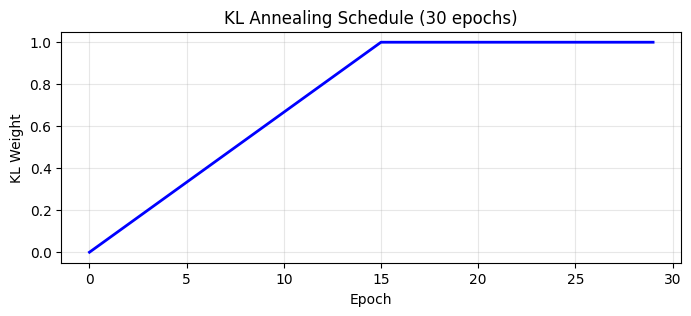

In [ ]:
def vae_loss(x, x_recon, mu, log_var, kl_weight):
    # Reconstruction loss — BCE between original and reconstructed pixels
    recon_loss = F.binary_cross_entropy(x_recon, x, reduction="sum") / x.size(0)

    # KL divergence — how far is learned distribution from N(0,1)
    # Formula: -0.5 * sum(1 + log_var - mu² - exp(log_var))
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / x.size(0)

    # Total loss — kl_weight anneals from 0 → 1 during training
    total_loss = recon_loss + kl_weight * kl_loss

    return total_loss, recon_loss, kl_loss


# KL annealing schedule — gradually increase KL weight
def get_kl_weight(epoch, total_epochs, max_weight=1.0):
    # Linear warmup over first 50% of training
    warmup_epochs = total_epochs // 2
    if epoch < warmup_epochs:
        return max_weight * (epoch / warmup_epochs)
    return max_weight


# Test the loss function
x_test            = torch.rand(4, 1, 28, 28).to(device)
x_recon_test, mu_test, log_var_test = model(x_test)

total, recon, kl  = vae_loss(x_test, x_recon_test, mu_test, log_var_test, kl_weight=0.5)
print(f"Total Loss       : {total.item():.4f}")
print(f"Reconstruction   : {recon.item():.4f}")
print(f"KL Divergence    : {kl.item():.4f}")

# Show KL annealing schedule
weights = [get_kl_weight(e, 30) for e in range(30)]
plt.figure(figsize=(8, 3))
plt.plot(weights, color="blue", linewidth=2)
plt.title("KL Annealing Schedule (30 epochs)")
plt.xlabel("Epoch")
plt.ylabel("KL Weight")
plt.grid(True, alpha=0.3)
plt.show()





# Implement the Variational Autoencoder loss function with KL divergence regularization and annealing support

# - Define the custom VAE loss combining Binary Cross-Entropy (reconstruction loss) and KL Divergence (latent regularization).
# - Introduce a configurable KL weight to balance reconstruction quality and latent space learning during training.
# - Implement a linear KL annealing schedule that gradually increases the influence of the KL term over the first half of training.
# - Validate the loss computation on sample data and visualize the KL weight schedule across training epochs.



# Implement the complete VAE optimization objective by combining reconstruction accuracy with probabilistic latent space regularization

# - Create the `vae_loss()` function that computes:
#   - Binary Cross-Entropy (BCE) reconstruction loss between the original image and reconstructed output.
#   - KL Divergence to measure how closely the learned latent distribution follows the standard normal distribution N(0,1).
#   - Total loss as: Reconstruction Loss + (KL Weight × KL Divergence).
# - Introduce the `kl_weight` parameter so the contribution of KL Divergence can be controlled throughout training.
# - Implement the `get_kl_weight()` function to perform linear KL annealing, gradually increasing the KL weight from 0 to 1 during the first 50% of training epochs.
# - Apply KL annealing to prevent the KL term from dominating training too early, allowing the decoder to first learn accurate image reconstruction before enforcing a structured latent space.
# - Test the loss function using randomly generated inputs and reconstructed outputs to verify correct computation of total, reconstruction, and KL losses.
# - Plot the KL annealing schedule to visualize how the regularization strength progressively increases over training.

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 30

# Track losses separately
train_total_losses = []
train_recon_losses = []
train_kl_losses    = []

print("Starting training...\n")

for epoch in range(EPOCHS):
    model.train()
    kl_weight = get_kl_weight(epoch, EPOCHS)

    epoch_total = 0
    epoch_recon = 0
    epoch_kl    = 0

    for batch_idx, (x, _) in enumerate(train_loader):
        x = x.to(device)

        optimizer.zero_grad()

        x_recon, mu, log_var = model(x)
        total, recon, kl     = vae_loss(x, x_recon, mu, log_var, kl_weight)

        total.backward()
        optimizer.step()

        epoch_total += total.item()
        epoch_recon += recon.item()
        epoch_kl    += kl.item()

    # Average over batches
    n_batches = len(train_loader)
    train_total_losses.append(epoch_total / n_batches)
    train_recon_losses.append(epoch_recon / n_batches)
    train_kl_losses.append(epoch_kl    / n_batches)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1:2d}/{EPOCHS}] "
              f"| KL Weight: {kl_weight:.2f} "
              f"| Total: {train_total_losses[-1]:.2f} "
              f"| Recon: {train_recon_losses[-1]:.2f} "
              f"| KL: {train_kl_losses[-1]:.2f}")

print("\nTraining complete!")






# Train the Variational Autoencoder using Adam optimization with KL annealing and monitor reconstruction and KL losses

# - Configure the Adam optimizer for updating the VAE parameters during training.
# - Train the VAE over multiple epochs while gradually increasing the KL divergence weight using KL annealing.
# - Record total loss, reconstruction loss, and KL divergence loss separately for each epoch.
# - Display training progress periodically to monitor convergence and the effect of KL annealing.


# Implement the complete VAE training pipeline by optimizing reconstruction quality and latent space regularization with adaptive KL weighting

# - Initialize the Adam optimizer with a learning rate of 1e-3 to efficiently update all trainable parameters of the VAE.
# - Define the total number of training epochs and create separate lists to store the average Total Loss, Reconstruction Loss, and KL Divergence Loss for each epoch.
# - Start the training loop by switching the model to training mode using `model.train()`, enabling training-specific behaviors such as stochastic latent sampling.
# - Compute the current KL weight at the beginning of every epoch using the KL annealing schedule so that latent space regularization gradually increases during training.
# - Iterate through mini-batches provided by the DataLoader, move each batch to the selected device, clear previous gradients, perform a forward pass, compute the VAE loss components, execute backpropagation, and update the model parameters using the Adam optimizer.
# - Accumulate the total, reconstruction, and KL losses for every batch and compute their average values at the end of each epoch to obtain stable training metrics.
# - Store the epoch-wise average losses for later visualization and analysis of the training process.
# - Print training statistics every five epochs, including the current KL weight and the corresponding loss values, allowing progress and convergence to be monitored throughout training.
# - Finish training after all epochs have completed, resulting in a fully trained VAE ready for reconstruction, latent space visualization, and image generation tasks.

Starting training...

Epoch [ 5/30] | KL Weight: 0.27 | Total: 261.77 | Recon: 259.42 | KL: 8.82
Epoch [10/30] | KL Weight: 0.60 | Total: 260.39 | Recon: 256.11 | KL: 7.14
Epoch [15/30] | KL Weight: 0.93 | Total: 260.76 | Recon: 254.62 | KL: 6.58
Epoch [20/30] | KL Weight: 1.00 | Total: 259.93 | Recon: 253.41 | KL: 6.52
Epoch [25/30] | KL Weight: 1.00 | Total: 259.22 | Recon: 252.66 | KL: 6.55
Epoch [30/30] | KL Weight: 1.00 | Total: 258.33 | Recon: 251.74 | KL: 6.59

Training complete!


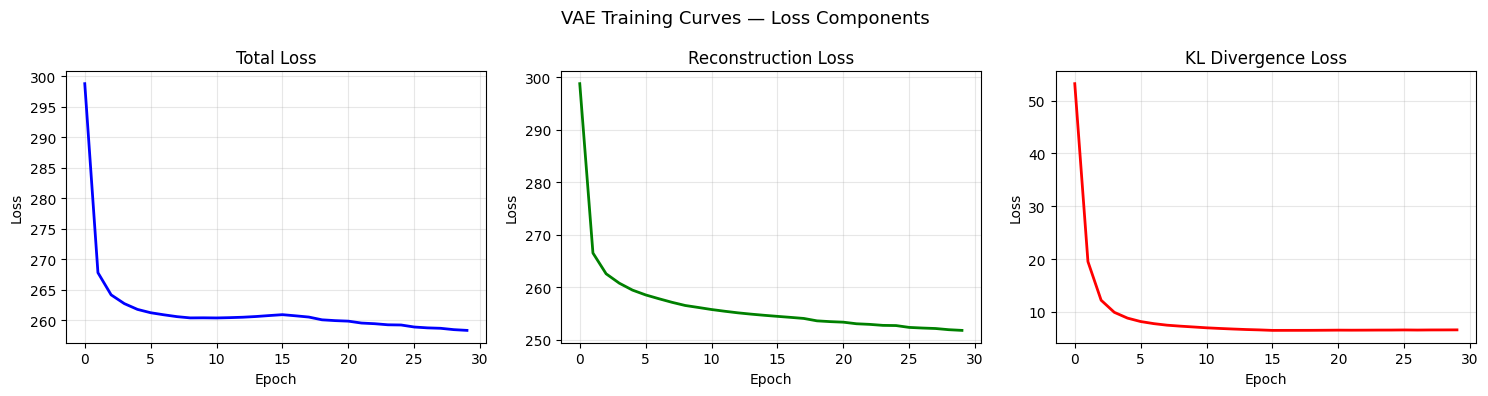

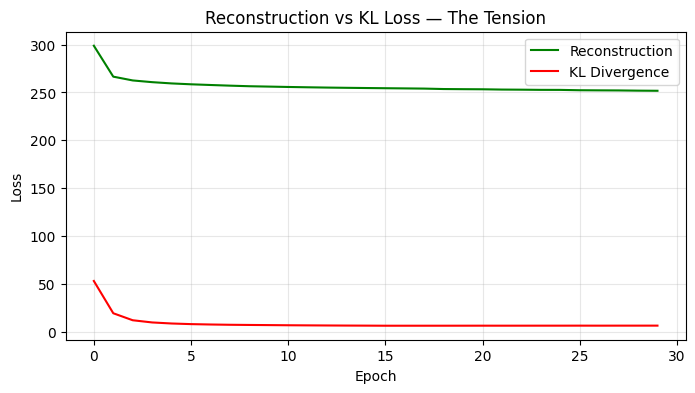

In [ ]:
 fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Total loss
axes[0].plot(train_total_losses, color="blue", linewidth=2)
axes[0].set_title("Total Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

# Reconstruction loss
axes[1].plot(train_recon_losses, color="green", linewidth=2)
axes[1].set_title("Reconstruction Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(True, alpha=0.3)

# KL divergence loss
axes[2].plot(train_kl_losses, color="red", linewidth=2)
axes[2].set_title("KL Divergence Loss")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Loss")
axes[2].grid(True, alpha=0.3)

plt.suptitle("VAE Training Curves — Loss Components", fontsize=13)
plt.tight_layout()
plt.show()

# Also plot together for comparison
plt.figure(figsize=(8, 4))
plt.plot(train_recon_losses, label="Reconstruction", color="green")
plt.plot(train_kl_losses,    label="KL Divergence",  color="red")
plt.title("Reconstruction vs KL Loss — The Tension")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()





# Visualize the Variational Autoencoder training dynamics by plotting individual and comparative loss curves

# - Plot the Total Loss, Reconstruction Loss, and KL Divergence Loss across all training epochs.
# - Display each loss component separately to analyze its convergence behavior during training.
# - Generate a combined comparison plot of Reconstruction Loss and KL Divergence Loss.
# - Provide visual insights into the optimization process and the balance between image reconstruction and latent space regularization.

# Analyze the VAE training process by visualizing how each loss component evolves throughout optimization

# - Create a three-panel figure to independently plot the Total Loss, Reconstruction Loss, and KL Divergence Loss recorded during training.
# - Plot the Total Loss to observe the overall optimization objective, which combines reconstruction accuracy with latent space regularization.
# - Plot the Reconstruction Loss separately to monitor how effectively the decoder learns to reproduce the original Fashion-MNIST images from the latent representations.
# - Plot the KL Divergence Loss independently to observe how the encoder gradually learns a latent distribution that approaches the standard normal distribution N(0,1).
# - Label each graph with descriptive titles, axis labels, and grid lines to improve readability and simplify interpretation of the training progress.
# - Generate an additional comparison graph that overlays the Reconstruction Loss and KL Divergence Loss on the same axes, making it easier to observe the trade-off between reconstruction quality and latent space regularization throughout training.
# - Demonstrate the fundamental optimization objective of Variational Autoencoders, where minimizing reconstruction loss encourages accurate image reconstruction while minimizing KL divergence organizes the latent space into a smooth, continuous distribution suitable for image generation and interpolation.

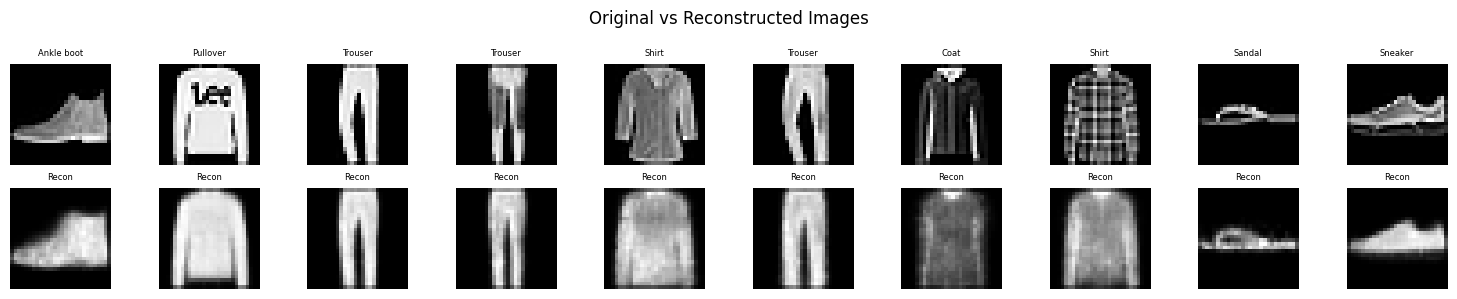

In [ ]:
model.eval()

# Get a batch of test images
test_images, test_labels = next(iter(test_loader))
test_images = test_images.to(device)

# Reconstruct
with torch.no_grad():
    reconstructed, _, _ = model(test_images)

# Plot original vs reconstructed
fig, axes = plt.subplots(2, 10, figsize=(15, 3))

for i in range(10):
    # Original
    axes[0][i].imshow(test_images[i].cpu().squeeze(), cmap="gray")
    axes[0][i].set_title(class_names[test_labels[i]], fontsize=6)
    axes[0][i].axis("off")

    # Reconstructed
    axes[1][i].imshow(reconstructed[i].cpu().squeeze(), cmap="gray")
    axes[1][i].set_title("Recon", fontsize=6)
    axes[1][i].axis("off")

axes[0][0].set_ylabel("Original",      fontsize=8)
axes[1][0].set_ylabel("Reconstructed", fontsize=8)

plt.suptitle("Original vs Reconstructed Images", fontsize=12)
plt.tight_layout()
plt.show()





# Evaluate the trained Variational Autoencoder by reconstructing test images and comparing them with the original inputs

# - Switch the trained VAE to evaluation mode for inference.
# - Generate reconstructed images from a batch of unseen test samples.
# - Display original and reconstructed images side by side for qualitative comparison.
# - Visualize the reconstruction capability of the trained VAE on Fashion-MNIST data.

# Evaluate the reconstruction performance of the trained Variational Autoencoder by generating and visualizing reconstructed versions of unseen Fashion-MNIST images

# - Switch the model to evaluation mode using `model.eval()` to disable training-specific behavior and ensure deterministic inference.
# - Retrieve one mini-batch of unseen test images and their corresponding class labels from the test DataLoader.
# - Move the input images to the selected computation device (CPU/GPU) before performing inference.
# - Disable gradient computation with `torch.no_grad()` to reduce memory usage and speed up the reconstruction process since no parameter updates are required.
# - Perform a forward pass through the VAE to obtain reconstructed images while ignoring the latent distribution outputs (`mu` and `log_var`) because only the reconstructed images are needed for visualization.
# - Create a two-row visualization where the first row displays the original Fashion-MNIST images and the second row displays their corresponding reconstructed outputs generated by the decoder.
# - Label the original images using their ground-truth class names and annotate the reconstructed row for easy comparison.
# - Present the original and reconstructed images side by side to qualitatively assess how effectively the trained VAE preserves the essential visual characteristics of unseen inputs.

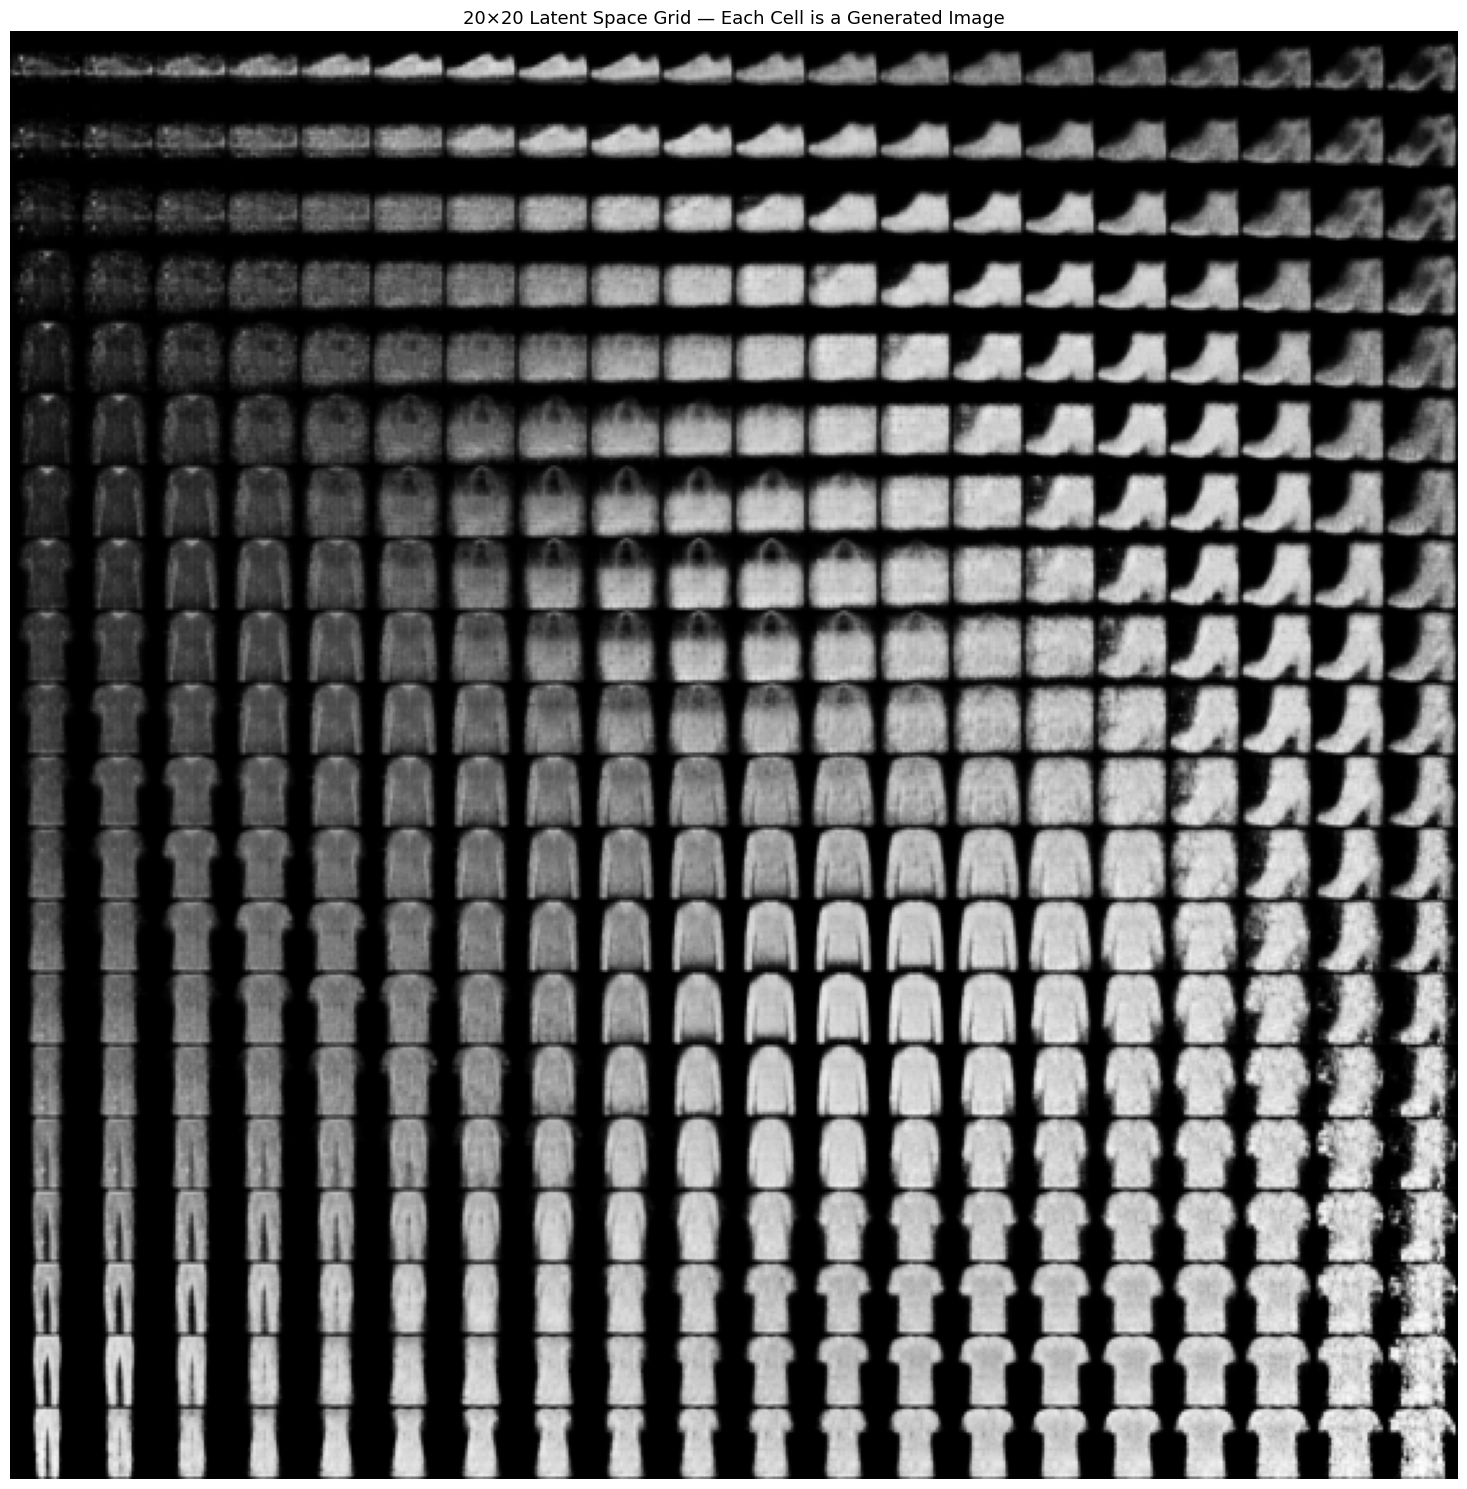

In [ ]:
model.eval()

n          = 20        # 20×20 grid
digit_size = 28
figure     = np.zeros((digit_size * n, digit_size * n))

# Sample evenly spaced points across the latent distribution
grid_x = stats.norm.ppf(np.linspace(0.05, 0.95, n))
grid_y = stats.norm.ppf(np.linspace(0.05, 0.95, n))

with torch.no_grad():
    for i, yi in enumerate(grid_x):
        for j, xi in enumerate(grid_y):
            z_sample = torch.tensor([[xi, yi]], dtype=torch.float32).to(device)
            x_decoded = model.decoder(z_sample)
            digit = x_decoded.cpu().squeeze().numpy()

            figure[
                i * digit_size : (i + 1) * digit_size,
                j * digit_size : (j + 1) * digit_size
            ] = digit

# Plot the full grid
plt.figure(figsize=(15, 15))
plt.imshow(figure, cmap="gray")
plt.title("20×20 Latent Space Grid — Each Cell is a Generated Image",
          fontsize=13)
plt.axis("off")
plt.tight_layout()
plt.show()





# Generate new images by sampling a 2D latent space grid and visualize the learned VAE manifold.
# Use Gaussian quantiles to systematically explore the latent distribution instead of random sampling.



# Generate a dense 20×20 visualization of the VAE's learned latent space by decoding hundreds of different latent vectors into images, allowing us to inspect what the model has learned after training.
# Instead of randomly sampling latent vectors, generate evenly spaced coordinates using the inverse cumulative Gaussian distribution (stats.norm.ppf), ensuring the samples cover the entire high-probability region of the latent space while avoiding extreme outliers.
# Create an empty canvas large enough to hold all generated images, where each 28×28 decoded image occupies one cell of the final 20×20 grid, making it easy to observe smooth transitions across the latent space.
# For every coordinate (x, y), treat it as a latent representation z, pass it directly into the trained decoder network, and reconstruct a completely new clothing image without providing any real input image to the encoder.
# Place each reconstructed image into its corresponding position on the large canvas so that neighboring latent coordinates appear next to one another, revealing how small changes in latent variables gradually change the generated clothing.
# Display the completed latent-space manifold, where moving horizontally or vertically corresponds to continuous changes in learned visual characteristics such as shape, style, orientation, or thickness of clothing items.
# This experiment demonstrates the defining property of Variational Autoencoders: because the KL-divergence regularizes the latent space to follow a smooth Gaussian distribution, almost every point can be decoded into a meaningful image, unlike a standard Autoencoder where many latent regions contain invalid or meaningless representations.
# The resulting grid provides qualitative evidence that the VAE has learned a continuous and structured latent manifold, making it suitable for image generation, interpolation, representation learning, and other generative modeling tasks.

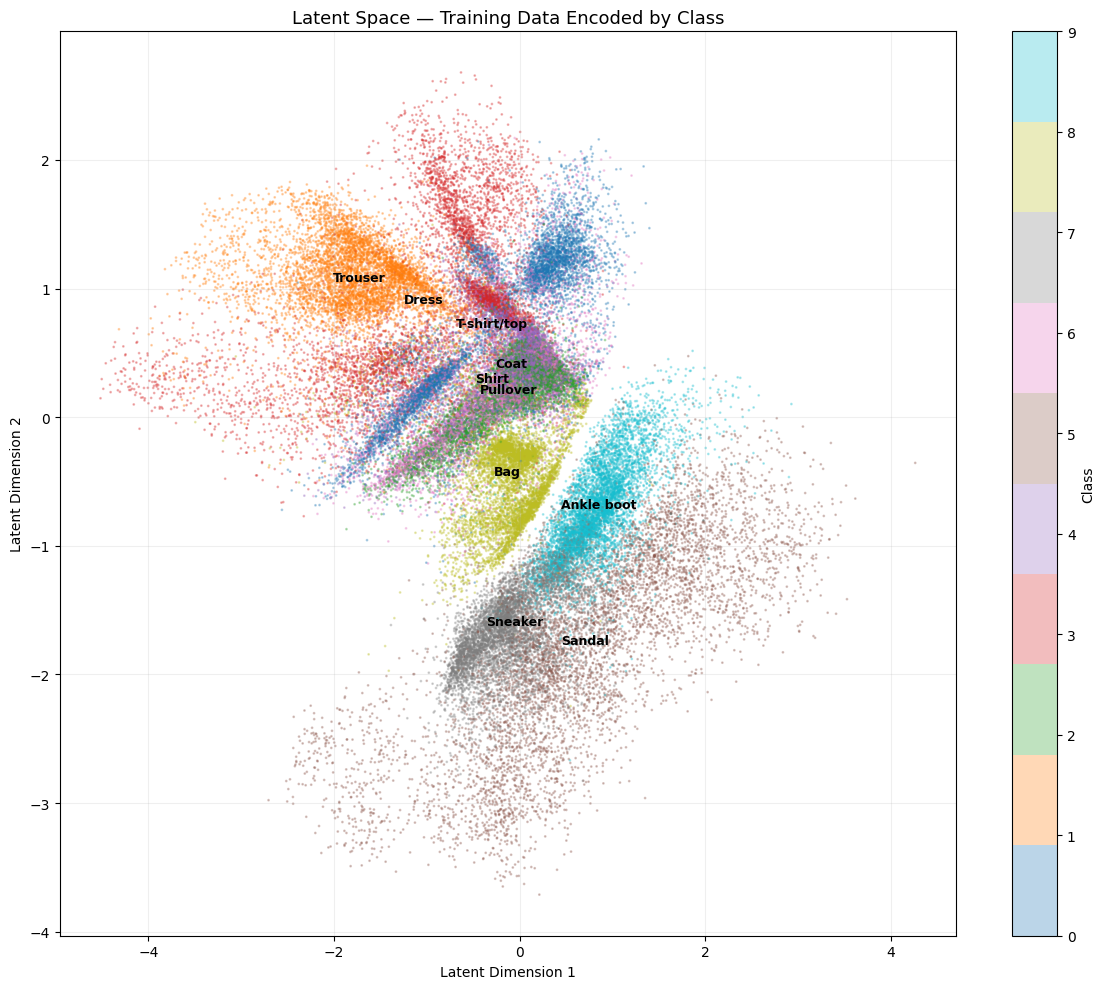

In [ ]:
model.eval()

all_mu     = []
all_labels = []

# Encode all training images
with torch.no_grad():
    for x, labels in train_loader:
        x = x.to(device)
        mu, _ = model.encoder(x)
        all_mu.append(mu.cpu().numpy())
        all_labels.append(labels.numpy())

all_mu     = np.concatenate(all_mu,     axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# Plot
plt.figure(figsize=(12, 10))
scatter = plt.scatter(
    all_mu[:, 0], all_mu[:, 1],
    c=all_labels, cmap="tab10",
    alpha=0.3, s=1
)

# Add class labels at cluster centers
for class_idx in range(10):
    mask    = all_labels == class_idx
    center_x = all_mu[mask, 0].mean()
    center_y = all_mu[mask, 1].mean()
    plt.annotate(class_names[class_idx],
                 (center_x, center_y),
                 fontsize=9,
                 fontweight="bold",
                 ha="center")

plt.colorbar(scatter, ticks=range(10), label="Class")
plt.title("Latent Space — Training Data Encoded by Class", fontsize=13)
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()






# Encode the entire training dataset into the VAE latent space and visualize class-wise clustering.
# Plot the learned 2D latent representations to evaluate how well the VAE organizes different Fashion-MNIST classes.




# Visualize the learned latent space by encoding every Fashion-MNIST training image into its corresponding latent representation (μ), allowing the organization of the learned feature space to be examined.
# Switch the Variational Autoencoder to evaluation mode using `model.eval()` so dropout and other training-specific operations are disabled, ensuring consistent and deterministic latent representations during visualization.
# Iterate through the entire training dataset without computing gradients (`torch.no_grad()`), pass every image through the encoder, and collect the latent mean (`μ`) together with the corresponding class labels for later visualization and analysis.
# Use the latent mean (`μ`) instead of randomly sampled latent vectors because the mean provides a stable and deterministic representation of each image's location within the learned latent space.
# Concatenate all encoded latent vectors and class labels into single NumPy arrays, producing a complete two-dimensional representation of the entire Fashion-MNIST training dataset in the VAE's latent manifold.
# Create a scatter plot where each point represents one encoded image, positioning it according to its two latent dimensions and coloring it by its true class label to reveal how the VAE groups similar clothing categories.
# Compute the centroid of each class by averaging the latent coordinates of all images belonging to that class, then annotate these cluster centers with their corresponding clothing names to improve interpretability of the latent space.
# Display the completed latent space visualization with class colors, labels, axis titles, and a color bar, providing qualitative evidence of how effectively the Variational Autoencoder has learned to separate, cluster, and organize visually similar Fashion-MNIST images within a continuous low-dimensional latent representation.

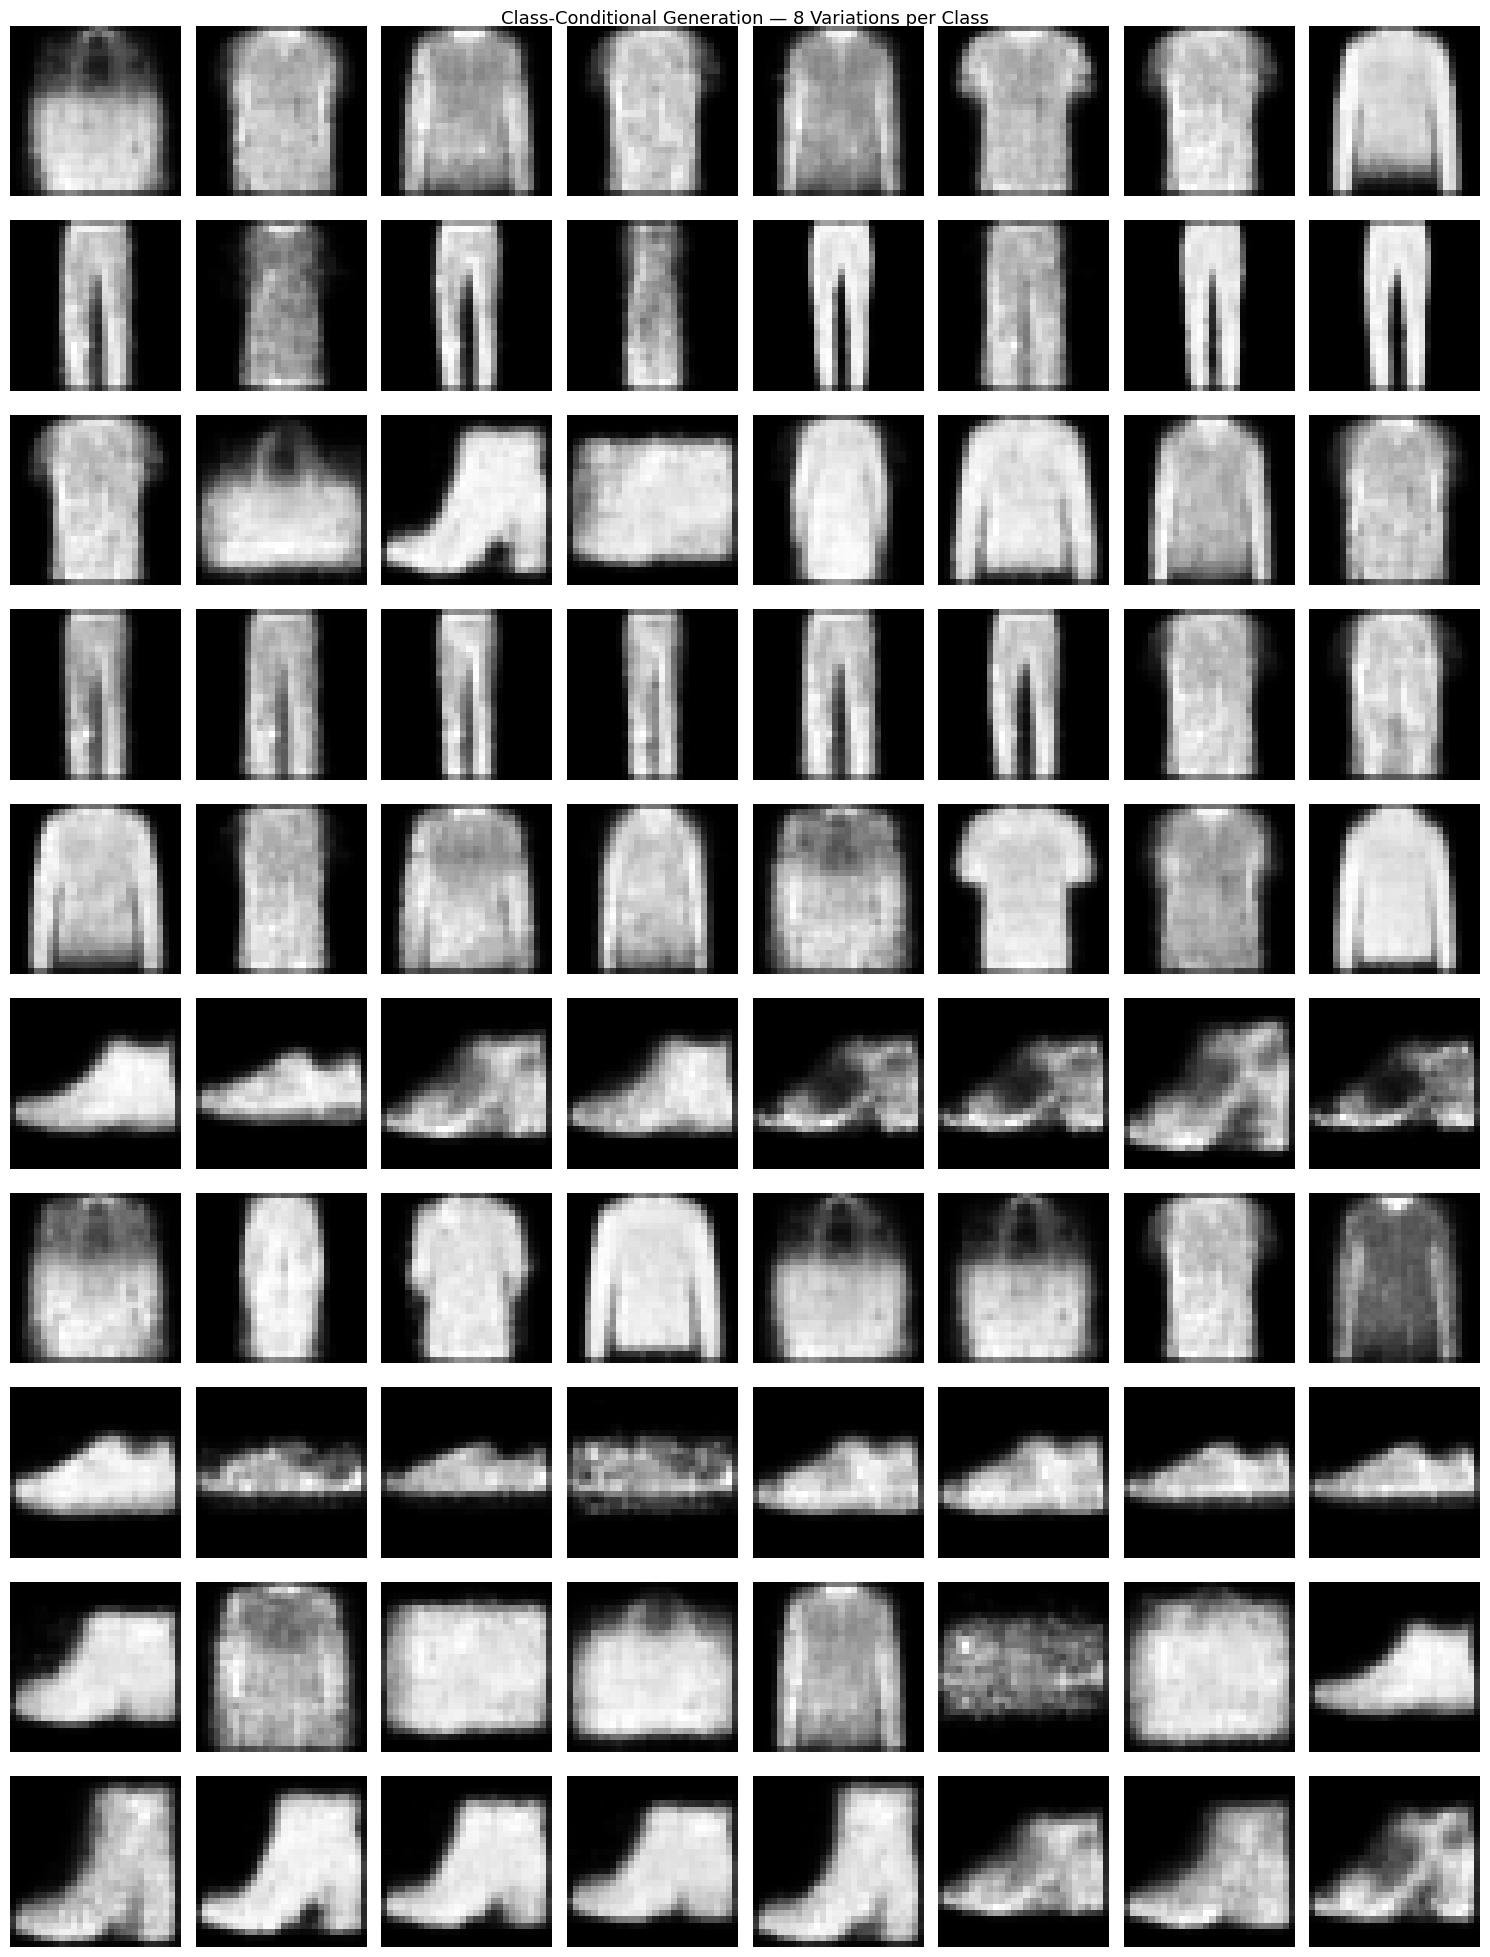

In [ ]:
model.eval()

# Step 1 — find the latent center of each class
class_centers = {}

with torch.no_grad():
    for x, labels in train_loader:
        x = x.to(device)
        mu, _ = model.encoder(x)
        for class_idx in range(10):
            mask = labels == class_idx
            if mask.sum() > 0:
                if class_idx not in class_centers:
                    class_centers[class_idx] = []
                class_centers[class_idx].append(mu[mask].cpu().numpy())

# Average all encodings per class to get center
for class_idx in range(10):
    class_centers[class_idx] = np.concatenate(
        class_centers[class_idx], axis=0
    ).mean(axis=0)

# Step 2 — generate 8 variations around each class center
n_variations = 8
noise_scale  = 0.5   # how far to sample from the center

fig, axes = plt.subplots(10, n_variations, figsize=(15, 20))

with torch.no_grad():
    for class_idx in range(10):
        center = torch.tensor(
            class_centers[class_idx], dtype=torch.float32
        ).to(device)

        for v in range(n_variations):
            # Sample around class center
            noise = torch.randn(2).to(device) * noise_scale
            z     = center + noise

            # Decode
            generated = model.decoder(z.unsqueeze(0))
            img       = generated.cpu().squeeze().numpy()

            axes[class_idx][v].imshow(img, cmap="gray")
            axes[class_idx][v].axis("off")

            if v == 0:
                axes[class_idx][v].set_ylabel(
                    class_names[class_idx], fontsize=8, rotation=0,
                    labelpad=60, va="center"
                )

plt.suptitle("Class-Conditional Generation — 8 Variations per Class",
             fontsize=13)
plt.tight_layout()
plt.show()





# Perform class-conditional image generation by sampling around each class center in the learned latent space.
# Decode multiple latent variations per class to visualize the diversity learned by the Variational Autoencoder.




# Generate class-specific synthetic Fashion-MNIST images by first identifying the latent-space center of each clothing category and then sampling nearby latent vectors to produce multiple realistic variations of the same class.
# Switch the Variational Autoencoder to evaluation mode using `model.eval()` so the encoder produces stable latent representations and all generated images remain deterministic throughout the visualization process.
# Encode every training image into its latent mean (`μ`) and group the resulting latent vectors according to their corresponding class labels, allowing the model to capture the distribution of each clothing category within the learned latent space.
# Compute the average latent representation for every Fashion-MNIST class by averaging all encoded vectors belonging to that class, producing a representative latent center that summarizes the typical characteristics of each clothing category.
# Sample multiple new latent vectors around each class center by adding small amounts of random Gaussian noise, generating slightly different latent representations while preserving the overall characteristics of the original clothing class.
# Decode every sampled latent vector using the trained decoder network to synthesize completely new Fashion-MNIST images, demonstrating that the decoder can generate realistic variations without requiring any input image from the encoder.
# Arrange the generated images into a structured visualization where each row represents one clothing category and each column shows a different randomly generated variation, making it easy to compare the diversity and consistency of generated samples within each class.
# Display the completed class-conditional generation grid, illustrating that the learned latent space preserves semantic information, allowing nearby latent vectors around the same class center to generate visually similar yet distinct clothing items while maintaining class-specific characteristics.

Pixel Statistics Comparison (FID-Inspired)
Metric                     Real    Generated
---------------------------------------------
Mean                     0.2888       0.3062
Std Dev                  0.3527       0.3140
Skewness                 0.6792       0.5121
Kurtosis                -1.2058      -1.3028
---------------------------------------------
Mean difference : 0.0174
Std  difference : 0.0387


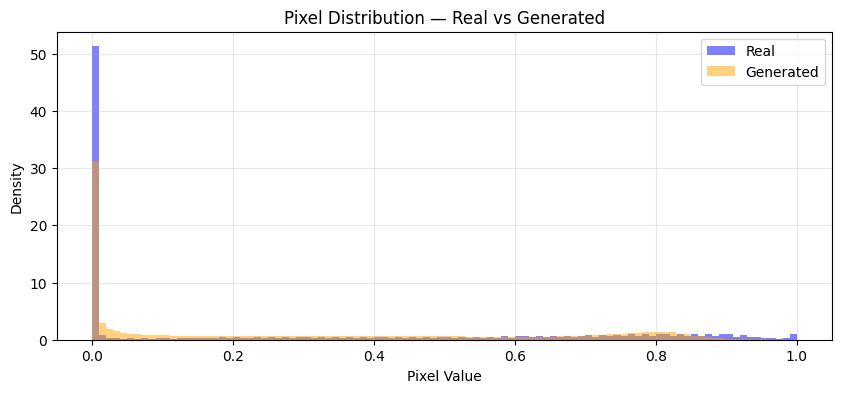

In [ ]:
model.eval()

# Collect real image pixel statistics
real_pixels = []
with torch.no_grad():
    for x, _ in test_loader:
        real_pixels.append(x.numpy().flatten())
        if len(real_pixels) >= 10:
            break
real_pixels = np.concatenate(real_pixels)

# Generate images and collect pixel statistics
generated_pixels = []
with torch.no_grad():
    for _ in range(10):
        z         = torch.randn(128, 2).to(device)
        generated = model.decoder(z)
        generated_pixels.append(generated.cpu().numpy().flatten())
generated_pixels = np.concatenate(generated_pixels)

# Compare statistics
real_mean = real_pixels.mean()
real_std  = real_pixels.std()
gen_mean  = generated_pixels.mean()
gen_std   = generated_pixels.std()

print("=" * 45)
print("Pixel Statistics Comparison (FID-Inspired)")
print("=" * 45)
print(f"{'Metric':<20} {'Real':>10} {'Generated':>12}")
print("-" * 45)
print(f"{'Mean':<20} {real_mean:>10.4f} {gen_mean:>12.4f}")
print(f"{'Std Dev':<20} {real_std:>10.4f} {gen_std:>12.4f}")
print(f"{'Skewness':<20} {stats.skew(real_pixels):>10.4f} {stats.skew(generated_pixels):>12.4f}")
print(f"{'Kurtosis':<20} {stats.kurtosis(real_pixels):>10.4f} {stats.kurtosis(generated_pixels):>12.4f}")
print("-" * 45)
print(f"Mean difference : {abs(real_mean - gen_mean):.4f}")
print(f"Std  difference : {abs(real_std  - gen_std):.4f}")

# Plot distributions
plt.figure(figsize=(10, 4))
plt.hist(real_pixels,      bins=100, alpha=0.5, label="Real",      color="blue",   density=True)
plt.hist(generated_pixels, bins=100, alpha=0.5, label="Generated", color="orange", density=True)
plt.title("Pixel Distribution — Real vs Generated")
plt.xlabel("Pixel Value")
plt.ylabel("Density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()







# Compare the statistical properties of real and VAE-generated images using pixel-level distribution analysis.
# Visualize and quantify how closely the generated images match the real Fashion-MNIST dataset.



# Evaluate the quality of the Variational Autoencoder's generated images by comparing their pixel-value distribution with that of real Fashion-MNIST images using simple statistical measures inspired by the intuition behind Fréchet Inception Distance (FID).
# Switch the trained VAE into evaluation mode using `model.eval()` to disable training-specific behavior and ensure all generated samples are produced consistently during the comparison.
# Collect pixel values from a subset of real test images by flattening each image into a one-dimensional array and combining them into a single distribution, providing a representative sample of the original dataset's pixel statistics.
# Generate an equal number of synthetic images by randomly sampling latent vectors from the standard normal distribution N(0,1), decoding them through the trained VAE decoder, flattening the generated outputs, and collecting their pixel values into a second distribution for comparison.
# Compute descriptive statistical measures including the mean, standard deviation, skewness, and kurtosis for both the real and generated pixel distributions, allowing quantitative assessment of how closely the generated images resemble the real dataset.
# Calculate the absolute differences between the means and standard deviations of the two distributions to provide a simple numerical indication of the similarity between real and generated image characteristics.
# Display all computed statistics in a formatted comparison table, making it straightforward to compare the overall distribution of pixel intensities between real and synthetic Fashion-MNIST images.
# Plot normalized histograms of the real and generated pixel distributions on the same graph, enabling a visual comparison of their probability density functions and providing qualitative evidence of how effectively the Variational Autoencoder has learned to reproduce the underlying pixel distribution of the training dataset.